In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression

In [5]:
import pandas as pd
import numpy as np

# Generate dataset
X, y = make_regression(
    n_samples=100,      # number of data points
    n_features=1,       # number of input features (linear regression → usually 1)
    n_informative=1,
    noise=10,           # noise added to target
    random_state=42     # for reproducibility
)

# Convert to DataFrame (optional but useful)
df = pd.DataFrame(X, columns=['Feature'])
df['Target'] = y

print(df.head())
df.info()

    Feature     Target
0  0.931280  50.779929
1  0.087047 -10.065270
2 -1.057711 -34.918392
3  0.314247  10.526743
4 -0.479174 -17.738377
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Feature  100 non-null    float64
 1   Target   100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


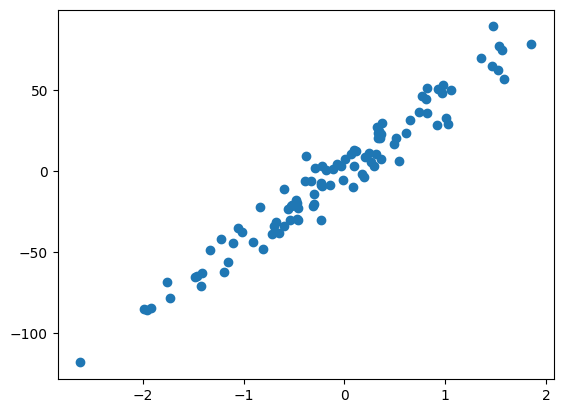

In [6]:
import matplotlib.pyplot as plt
plt.scatter(df['Feature'], df['Target'])
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred = model.predict(X_test)

In [10]:
mean_squared_error(y_pred, y_test)

104.20222653187027

In [11]:
model.coef_[0], model.intercept_

(44.24418215597419, 0.09922221422587718)

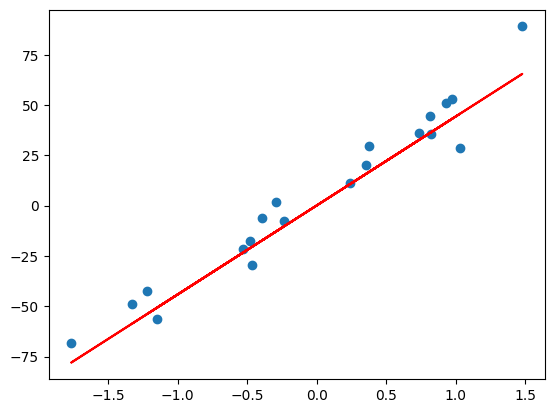

In [12]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.show()

In [13]:
from sklearn.metrics import r2_score

r2_score(y_pred, y_test)

0.9333880091299308

In [55]:
class GD_regressor:
    def __init__(self, iterats=1000, learningRate=0.01):
        self.curr_m = 0.0
        self.curr_b = 0.0
        self.iterats = iterats
        self.learningRate = learningRate
        self.cost_history = []
        
    def train(self, X, y):
        n = len(X)
        
        for i in range(self.iterats):
            
            # slope of partial derivatives
            dm = (2) * np.sum(X.ravel() * ((self.curr_m * X.ravel() + self.curr_b) - y))
            db = (2) * np.sum((self.curr_m * X.ravel() + self.curr_b) - y)
            
            # direction to downward in gradient
            self.curr_m = self.curr_m - self.learningRate * dm
            self.curr_b = self.curr_b - self.learningRate * db
            
            # cost calculation
            error = y - (self.curr_m * X + self.curr_b)
            self.cost_history.append((np.mean(error**2)) / 2)
        print(self.curr_m, self.curr_b)
        
    
    def predict(self, X):
        return self.curr_m * X + self.curr_b;

In [56]:
# Generate dataset
X, y = make_regression(
    n_samples=100,      # number of data points
    n_features=1,       # number of input features (linear regression → usually 1)
    n_informative=1,
    noise=10,           # noise added to target
    random_state=42     # for reproducibility
)

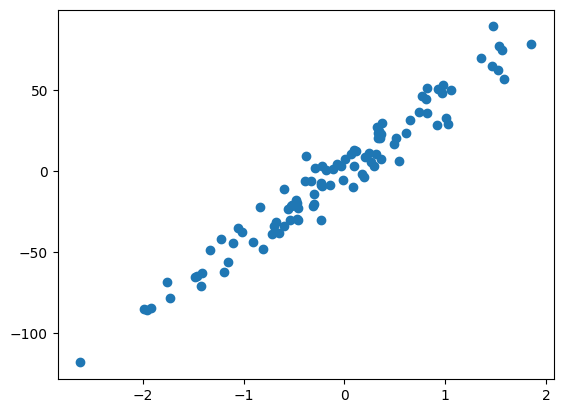

In [57]:
plt.scatter(X, y)
plt.show()

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
gd = GD_regressor(iterats=1000, learningRate=0.01)
gd.train(X_train, y_train)

44.2441821559742 0.09922221422588233


In [60]:
y_pred_GD = gd.predict(X_test)
y_pred_GD.shape


(20, 1)

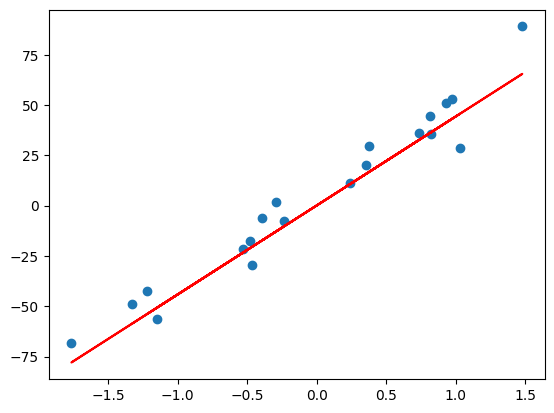

In [61]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_GD, color='red')
plt.show()

In [62]:
r2_score(y_test, y_pred_GD)

0.9374151607623286

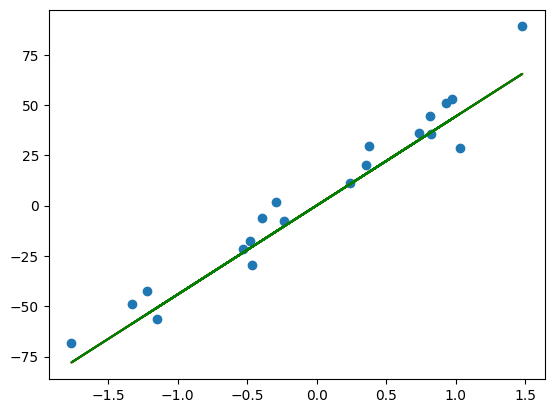

In [63]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.plot(X_test, y_pred_GD, color='green')
plt.show()

In [64]:
gd.cost_history,

([2322.3492060490203,
  1453.3336960403926,
  1814.2989011470856,
  1555.9675590148422,
  1713.0643326741358,
  1593.494086821553,
  1673.44552599439,
  1614.1447556700289,
  1655.1253641693077,
  1625.3109803500163,
  1646.2276819824258,
  1631.1672423335788,
  1641.8125641012996,
  1634.1883184873645,
  1639.597890842266,
  1635.733960776649,
  1638.480776604164,
  1636.5214748504127,
  1637.9156742716568,
  1636.9218832531121,
  1637.6293946142564,
  1637.1252552963429,
  1637.484258147423,
  1637.2284953246324,
  1637.4106498803626,
  1637.2808900797913,
  1637.3733111183456,
  1637.3074770046694,
  1637.3543686964613,
  1637.3209672009968,
  1637.3447584938085,
  1637.3278118809603,
  1637.3398827545661,
  1637.3312846849253,
  1637.3374090153195,
  1637.3330466749953,
  1637.3361539389016,
  1637.3339406485018,
  1637.335517161208,
  1637.3343942190297,
  1637.3351940840646,
  1637.3346243443957,
  1637.3350301666883,
  1637.3347411016564,
  1637.3349470010476,
  1637.33480034003

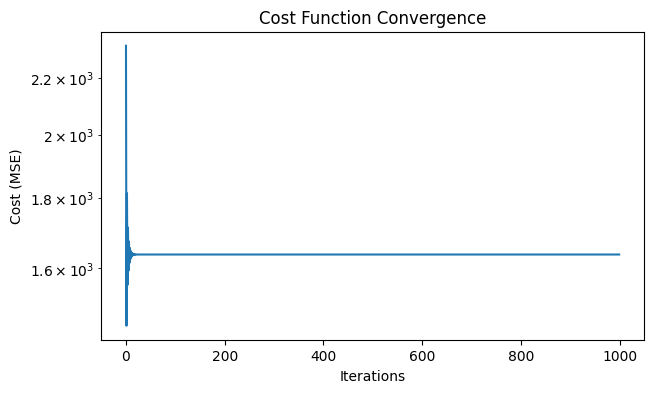

In [66]:
plt.figure(figsize=(7,4))
plt.plot(gd.cost_history)
plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Cost Function Convergence")
# plt.grid(True)
plt.show()

In [43]:
len(gd.cost_history), 

(5000,)